# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv").head()



In [3]:
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [ ]:
import pandas as pd
from io import StringIO



X = df[['Experience Years']] 
y = df['Salary']           

print("X (Features) first 5 rows:")
print(X.head(20))
print("\ny (Target) first 5 rows:")
print(y.head(20))

X (Features) first 5 rows:
   Experience Years
0               1.1
1               1.2
2               1.3
3               1.5
4               2.0

y (Target) first 5 rows:
0    39343
1    42774
2    46205
3    37731
4    43525
Name: Salary, dtype: int64


### Step 2.b print the type of each

In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  5 non-null      float64
dtypes: float64(1)
memory usage: 172.0 bytes


In [6]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

The target is numerical and the task is regression. 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


print(f"\nData Matrix (X) has {X.shape[0]} samples and {X.shape[1]} column.")
print(f"Target Vector (y) has {len(y)} samples.")

X shape: (5, 1)
y shape: (5,)

Data Matrix (X) has 5 samples and 1 column.
Target Vector (y) has 5 samples.


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [ ]:
summary = df.describe()


specific_stats = summary.loc[['min', 'max', '50%', 'mean', 'std']]
print(specific_stats)

      Experience Years        Salary
min           1.100000  37731.000000
max           2.000000  46205.000000
50%           1.300000  42774.000000
mean          1.420000  41915.600000
std           0.356371   3385.820403


### Step 5. Plot the feature vs the target

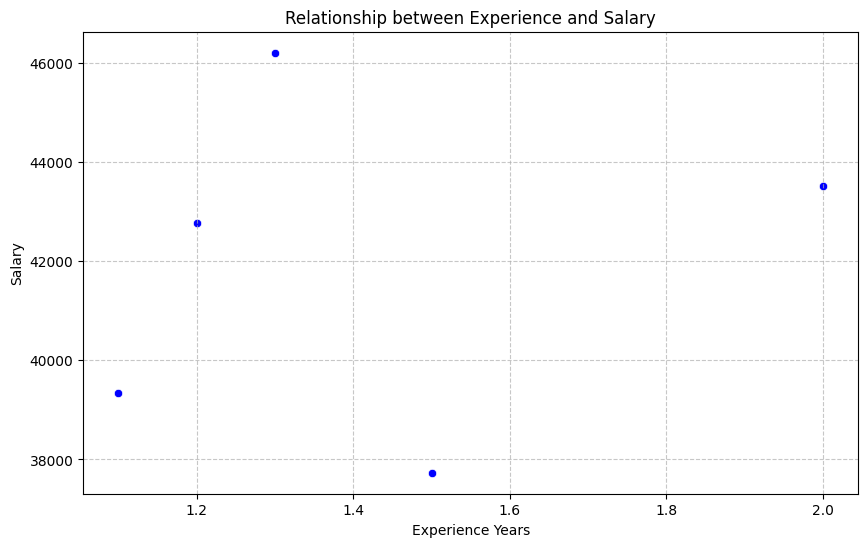

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Experience Years', y='Salary', color='blue')

# Adding titles and labels for clarity
plt.title('Relationship between Experience and Salary')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

It is increasing.

### Step 7. Initialize a regression model

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Initialize the model
model = LinearRegression()

print("Model successfully initialized!")
print(model)

Model successfully initialized!
LinearRegression()


### Step 8. Split the dataset into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4
Testing samples: 1


### Step 9.a Train the model on the training set

In [ ]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [ ]:

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (Coefficient): {slope:.2f}")
print(f"Y-intercept: {intercept:.2f}")

Slope (Coefficient): 2132.74
Y-intercept: 38555.21


### Step 9.c how much salary does a person get with 2 years of experience?

In [ ]:
prediction = model.predict([[2]])

print(f"Predicted salary for 2 years of experience: ${prediction[0]:,.2f}")

Predicted salary for 2 years of experience: $42,820.69


c:\Users\feras\Desktop\SDAIA2\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [ ]:
slope = model.coef_[0]

six_month_increase = slope * 0.5

print(f"An increase of 6 months adds: ${six_month_increase:,.2f}")

An increase of 6 months adds: $1,066.37


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [ ]:
zero_exp_salary = model.predict([[0]])

print(f"Estimated starting salary (0 years): ${zero_exp_salary[0]:,.2f}")
print(f"Model Intercept: ${model.intercept_:,.2f}")

Estimated starting salary (0 years): $38,555.21
Model Intercept: $38,555.21


c:\Users\feras\Desktop\SDAIA2\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 10. Evaluate the model on the test set

In [ ]:
y_pred = model.predict(X_test)


import pandas as pd
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head())

   Actual     Predicted
1   42774  41114.497207


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [ ]:
sample_X = X_test.sample(3, random_state=1, replace=True)
sample_y = y_test.loc[sample_X.index]

sample_preds = model.predict(sample_X)


comparison = pd.DataFrame({
    'Experience (Years)': sample_X.values.flatten(),
    'Actual Salary': sample_y.values,
    'Predicted Salary': sample_preds.round(2)
})

# 4. Calculate the 'Error' (The difference)
comparison['Difference'] = (comparison['Actual Salary'] - comparison['Predicted Salary']).abs()

print(comparison)

   Experience (Years)  Actual Salary  Predicted Salary  Difference
0                 1.2          42774           41114.5      1659.5
1                 1.2          42774           41114.5      1659.5
2                 1.2          42774           41114.5      1659.5


### Step 12. Plot the data and the regression line

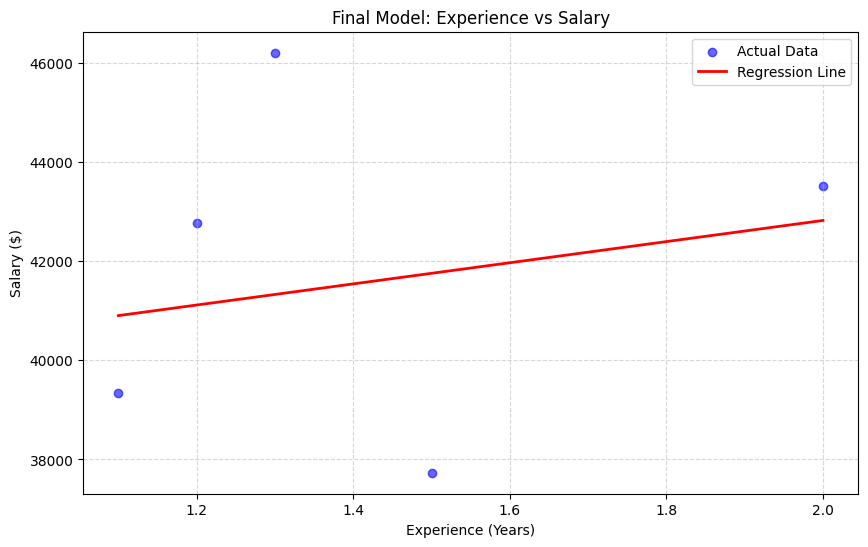

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.6)


plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')


plt.title('Final Model: Experience vs Salary')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
